<h2 style='color:blue' align='center'>Implementation of Stochastic ,Mini Batch and Batch grandient descent in python</h2>

https://www.youtube.com/watch?v=IU5fuoYBTAM&list=PLeo1K3hjS3uu7CxAacxVndI4bE_o3BDtO&index=14

#### Batch Gradient Descent:

- We will use very simple home prices data set to implement batch and stochastic gradient descent in python. Batch gradient descent uses **all** training samples in forward pass to calculate cumulitive error and than we adjust weights using derivaties. 

#### Stochastic Gradient Descent:
- In stochastic GD, we randomly pick **one** training sample, perform forward pass, compute the error and immidiately adjust weights. 

- So the key difference here is that to adjust weights **batch GD** will use **all** training samples where as **Stochastic GD** will use **one randomly picked training sample**


#### Mini batch Gradient Descent:
- In Mini batch GD, we randomly pick **Batch of Random** training sample, perform forward pass, compute the error and immidiately adjust weights. 
- Here we will mention no of sample to consider in each iteration as **batch_size**

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

##### Load the dataset in pandas dataframe

In [2]:
df = pd.read_csv("homeprices_banglore.csv")
df.sample(5)

,area,bedrooms,price
7,3300,4,155.0
4,1200,2,51.0
13,1100,2,40.0
1,2600,4,120.0
2,1440,3,62.0


In [3]:
df.shape

(20, 3)

### Preprocessing/Scaling: Since our columns are on different sacle it is important to perform scaling on them

In [4]:
from sklearn import preprocessing
sx = preprocessing.MinMaxScaler()
sy = preprocessing.MinMaxScaler()

scaled_X = sx.fit_transform(df.drop('price',axis='columns'))  # Area, bedrooms
scaled_y = sy.fit_transform(df['price'].values.reshape(df.shape[0],1)) # price

scaled_X

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [6]:
scaled_X.shape
# 20 row 2 col

(20, 2)

In [7]:
print(scaled_y.shape)
scaled_y

(20, 1)


array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

### We should convert target column (i.e. price) into one dimensional array. It has become 2D due to scaling that we did above but now we should change to 1D

> hmmmm need to be careful such things...didn't observe this myself before reading the above comment. 

In [8]:
scaled_y.reshape(20,)

array([0.05237037, 0.65185185, 0.22222222, 0.31851852, 0.14074074,
       0.04444444, 0.76296296, 0.91111111, 0.13333333, 1.        ,
       0.37037037, 0.8       , 0.04444444, 0.05925926, 0.51111111,
       0.07407407, 0.11851852, 0.20740741, 0.51851852, 0.        ])

In [9]:
scaled_y.shape
# Now its 1 D array with single []

(20, 1)

##### Gradient descent allows you to find weights (w1,w2) and bias in following linear equation for housing price prediction

<img src="hp.jpg"/>

# 1.  Batch Gradient Descent. 
##### Now is the time to implement batch gradient descent. 

In [10]:
np.ones(shape=(2))  # this is just to understand the inside code. 
# This craetes 1-D array of value as 1 with shape=2(here 2 is no of feature in X)

array([1., 1.])

In [16]:
scaled_X.shape 

(20, 2)

In [17]:
scaled_X.shape[1] 
# This gives 2nd value in tuple, which is no of features

2

In [24]:
# Here Transpose will converts 20 row 2 col data to 2 row 20 col data, which is essential during applying dot multiplication
# Without Transpose, it does dot multiplication wrongly, not as our expected

print(scaled_X[:6])
print("\n",scaled_X.shape)
print("\n",scaled_X.T[:6])
print("\n",scaled_X.T.shape)

[[0.08827586 0.25      ]
 [0.62068966 0.75      ]
 [0.22068966 0.5       ]
 [0.24862069 0.5       ]
 [0.13793103 0.25      ]
 [0.12758621 0.25      ]]

 (20, 2)

 [[0.08827586 0.62068966 0.22068966 0.24862069 0.13793103 0.12758621
  0.6662069  0.86206897 0.17586207 1.         0.34482759 0.68448276
  0.06896552 0.10344828 0.5        0.12931034 0.13103448 0.25517241
  0.67931034 0.        ]
 [0.25       0.75       0.5        0.5        0.25       0.25
  0.75       0.75       0.5        1.         0.5        0.75
  0.25       0.25       0.5        0.25       0.5        0.5
  0.5        0.        ]]

 (2, 20)


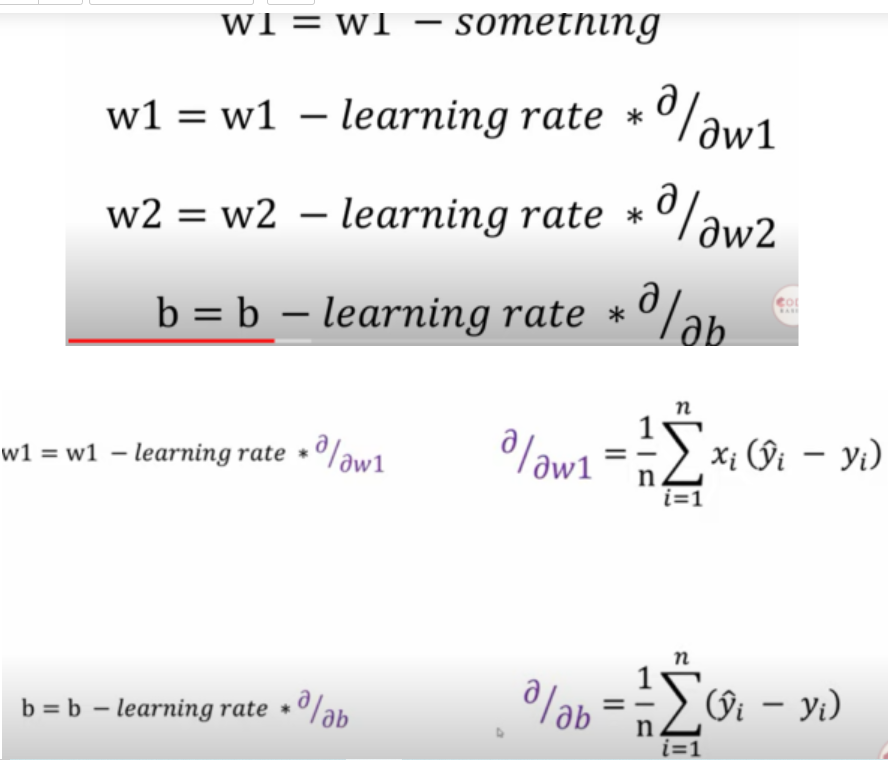

In [25]:
def batch_gradient_descent(X, y_true, epochs, learning_rate = 0.01):

    number_of_features = X.shape[1]  # number of coumns in X
    # our case number_of_features = 2 (area, bedroom)
    
    # Here ceates w1 and w2 coeffiecient=1 as single array
    w = np.ones(shape=(number_of_features))  # This craetes 1-D array of value as 1 with shape=2(here 2 is no of feature in X)
    b = 0
    total_samples = X.shape[0] # number of rows in X
    
    cost_list = []
    epoch_list = []
    
    
    for i in range(epochs):    
        
        # due to Transpose and W array [w1,w2], it does dot operation as row by row as we expected
        # w1*area + w2*bedroom + bias is achieved using np.dot product function here.
        # dot(w, X.T) --> (1,2) * (2*20) = (1*20) --> 1 row 20 col, which is price
        
        y_predicted = np.dot(w, X.T) + b         
        # T is transpose 

        # here we are finding derivative of error w.r.t weight and bias.
        # we named that as w_gradient and b_gradient
        #This is like : Derivative(w)  ---> w_grad = 1/n{Xi *(Ytru-Ypred)}   --> Dont know - used here
        w_grad = -(2/total_samples)*(X.T.dot(y_true-y_predicted))
        b_grad = -(2/total_samples)*np.sum(y_true-y_predicted)

        
        #This is like : w1 = w1 - lear_rate*Derivative(cost)  ---> w1 = w1 - w_grad
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad
        # calculate the new weights and bias. 
        
        
        cost = np.mean(np.square(y_true-y_predicted)) # MSE (Mean Squared Error)
        
        
        if i%10==0:
            cost_list.append(cost)
            epoch_list.append(i)
        
    return w, b, cost, cost_list, epoch_list

In [26]:
w, b, cost, cost_list, epoch_list = batch_gradient_descent(scaled_X,scaled_y.reshape(scaled_y.shape[0],),500)

w, b, cost

(array([0.70712464, 0.67456527]), -0.23034857438407427, 0.0068641890429808105)

###### Check price equation above. In that equation we were trying to find values of w1,w2 and bias. Here we got these values for each of them,
- w1 = 0.70712464

- w2 = 0.67456527

- bias = -0.23034857438407427

- MSE/ Cost = 0.0068641890429


> This is the final best coefficient and bias value after Batch gradient descent with Epoch/Iteration = 500, This trained vallue we will use to fit final model prediction

###### Now plot epoch vs cost graph to see how cost reduces as number of epoch increases

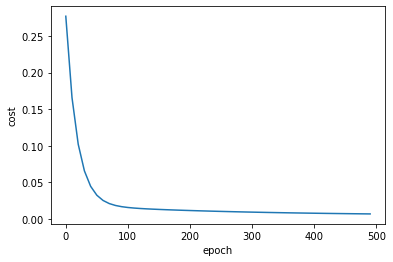

In [27]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list,cost_list)

### Lets do some predictions now. 

> We are passing original data to predict function and inside we will do scaling which we did earlier. Later reversed data returned

In [28]:
def predict(area,bedrooms,w,b):
    
    # Scale the input [area , bedrooms] with minmax scaler
    scaled_X = sx.transform([[area, bedrooms]])[0]
    
    # here w1 = w[0] , w2 = w[1] and bias is b
    # equation for price is w1*area + w2*bedrooms + w3*age + bias
    # scaled_X[0] is area
    # scaled_X[1] is bedrooms
    
    
    #Here w[0] is single value, not a array, so not req dot multiplication here
    scaled_price = w[0] * scaled_X[0] + w[1] * scaled_X[1] + b
    
    # once we get price prediction we need to to rescal it back to original value
    # also since it returns 2D array, to get single value we need to do value[0][0]
    return sy.inverse_transform([[scaled_price]])[0][0]

In [29]:
predict(2600,4,w,b)

128.45484403267596

In [30]:
predict(1000,2,w,b)

30.253094462442355

In [31]:
predict(1500,3,w,b)

69.47860785714694


# 2.  Stochastic Gradient Descent Implementation

#### Stochastic GD will use randomly picked single training sample to calculate error and using this error we backpropage to adjust weights

In [33]:
# we will use random libary to pick random training sample.
import random
random.randint(0,6) # randit gives random number between two numbers specified in the argument
#It provides one random value

3

In [35]:
# Use same as Batch Gradient Descent code, just passing value take random 1 row instead of all rows
# Use more epoch compared to batch GD, coz it takes 1 row to check error and adjust weights

def stochastic_gradient_descent(X, y_true, epochs, learning_rate = 0.01):
 
    number_of_features = X.shape[1]
    # numpy array with 1 row and columns equal to number of features. In 
    # our case number_of_features = 3 (area, bedroom and age)
    w = np.ones(shape=(number_of_features)) 
    b = 0
    total_samples = X.shape[0]
    
    cost_list = []
    epoch_list = []
    
    for i in range(epochs):  
        
        random_index = random.randint(0,total_samples-1) # random index from total samples
        sample_x = X[random_index]
        sample_y = y_true[random_index]
        
        y_predicted = np.dot(w, sample_x.T) + b
    
        w_grad = -(2/total_samples)*(sample_x.T.dot(sample_y-y_predicted))
        b_grad = -(2/total_samples)*(sample_y-y_predicted)
        
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad
        
        cost = np.square(sample_y-y_predicted)
        
        if i%100==0: # at every 100th iteration record the cost and epoch value
            cost_list.append(cost)
            epoch_list.append(i)
        
    return w, b, cost, cost_list, epoch_list


In [36]:
w_sgd, b_sgd, cost_sgd, cost_list_sgd, epoch_list_sgd = stochastic_gradient_descent (scaled_X,scaled_y.reshape(scaled_y.shape[0],),10000)

w_sgd, b_sgd, cost_sgd

(array([0.70771517, 0.67328857]), -0.2317157081361705, 0.0007742450183363564)

- Compare this with weights and bias that we got using gradient descent. They both of quite similar.

- w1 = 0.70712464

- w2 = 0.67456527

- bias = -0.23034857438407427

- MSE/ Cost = 0.000774245


> This is the final best coefficient and bias value after Stochastic Gradient descent with Epoch/Iteration = 10000, This trained value we will use to fit final model prediction

In [37]:
w , b 

(array([0.70712464, 0.67456527]), -0.23034857438407427)

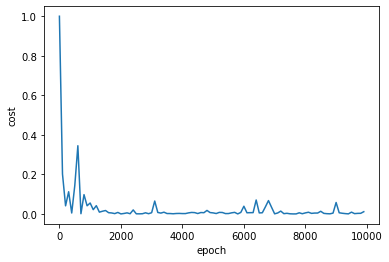

In [38]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list_sgd,cost_list_sgd)

> In SGD, Cost vs epoch is not smooth curve, Starting its fluctuating a lot coz it consideres 1 row and adjust the coefficient, Later it becomes smooth, so we need to consider high Epoch in SGD

In [39]:
print('Prediction by SGD:', predict(2600,4,w_sgd, b_sgd))
print('Prediction by BGD:', predict(2600,4,w,b))

Prediction by SGD: 128.19049811465214
Prediction by BGD: 128.45484403267596


In [40]:
print('Prediction by SGD:', predict(1000,2,w_sgd, b_sgd))
print('Prediction by BGD:', predict(1000,2,w, b))

Prediction by SGD: 30.0309410769829
Prediction by BGD: 30.253094462442355


In [41]:
print('Prediction by SGD:', predict(1500,3,w_sgd, b_sgd))
print('Prediction by BGD:', predict(1500,3,w, b))

Prediction by SGD: 69.22711117408318
Prediction by BGD: 69.47860785714694


#### we can see that even though SGD picks random records to get trained, it does pretty good job and gives prediction 
#### Its Prediction almost nearer to BGD.

<h3 style='color:purple'>Exercise</h3>

#### Implement mini batch gradient descent in python and plot cost vs epoch graph. Mini batch is intermediate version of batch GD and stochastic GD. In stochastic we used one randomly picked training sample, In mini gradient descent you will use a batch of samples in each iterations. For example if you have total 50 training samples, you can take a batch of 10 samples, calculate cumulitive error for those 10 samples and then adjust weights. In SGD we adjust weights after every one sample. In Batch we adjust weights after going through all samples but in mini batch we do after every m samples (where m is batch size and it is 0 < m < n, where n is total number of samples



[Solution](https://github.com/codebasics/py/blob/master/DeepLearningML/8_sgd_vs_gd/mini_batch_gd.ipynb)